In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import seaborn as sns

from paper.models import KthEigval, KthEigval1DMonotone
from paper.synth_fn import random_func, random_inc_func
from paper.training import Synthetic1DStream, compute_scaling_law
from paper.plotting import func_gallery

mpl.rcParams['figure.dpi'] = 140

# General functions

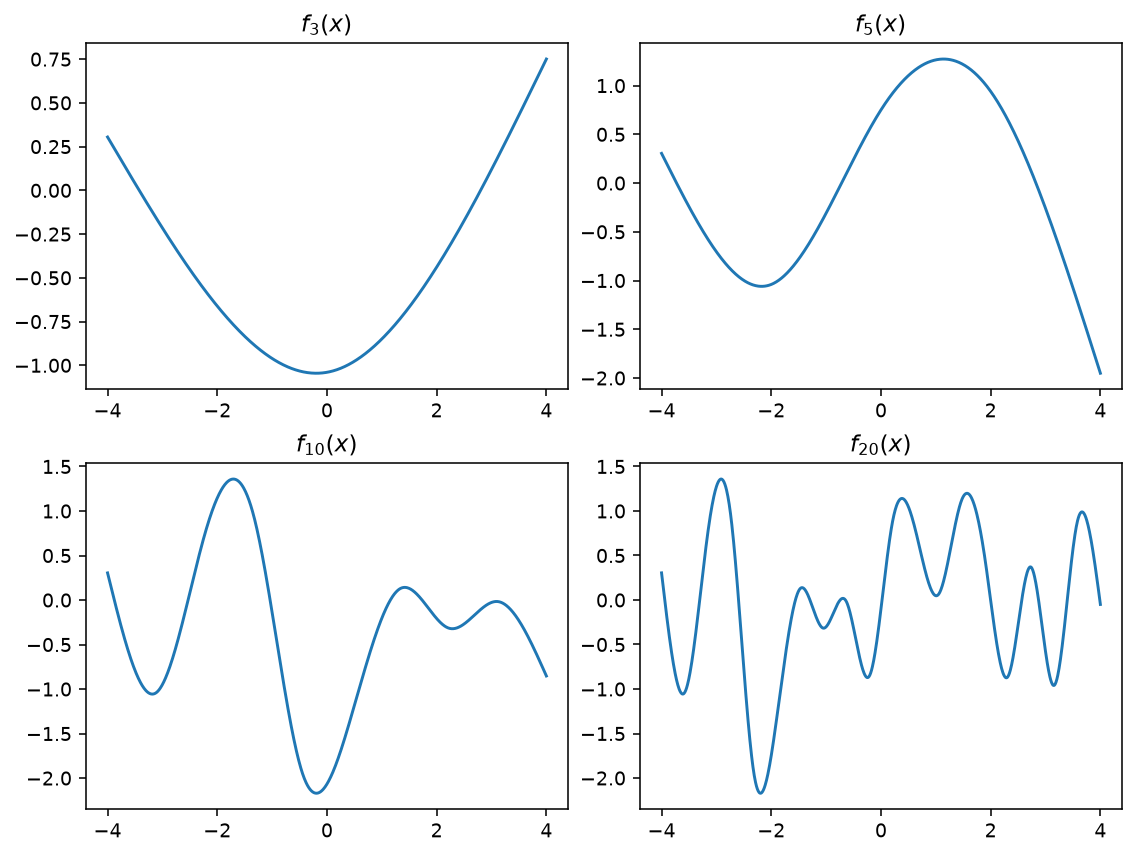

In [2]:
func_gallery(random_func)
plt.show()

In [5]:
dims = [3, 5, 10]
complexities = [3, 5, 10, 20]
scaling_laws = []
for complexity in complexities:
    for dim in dims:
        scaling_law = compute_scaling_law(
            Synthetic1DStream(random_func(complexity)),
            lambda: KthEigval(1, dim)
        )
        scaling_law['dim'] = dim
        scaling_law['complexity'] = complexity
        scaling_laws.append(scaling_law.reset_index())
        print(f'Computed dim={dim}, complexity={complexity}')

Computed dim=3, complexity=3
Computed dim=5, complexity=3
Computed dim=10, complexity=3
Computed dim=3, complexity=5
Computed dim=5, complexity=5
Computed dim=10, complexity=5
Computed dim=3, complexity=10
Computed dim=5, complexity=10
Computed dim=10, complexity=10
Computed dim=3, complexity=20
Computed dim=5, complexity=20
Computed dim=10, complexity=20


In [8]:
scaling_laws_df = pd.concat(scaling_laws, axis=0)

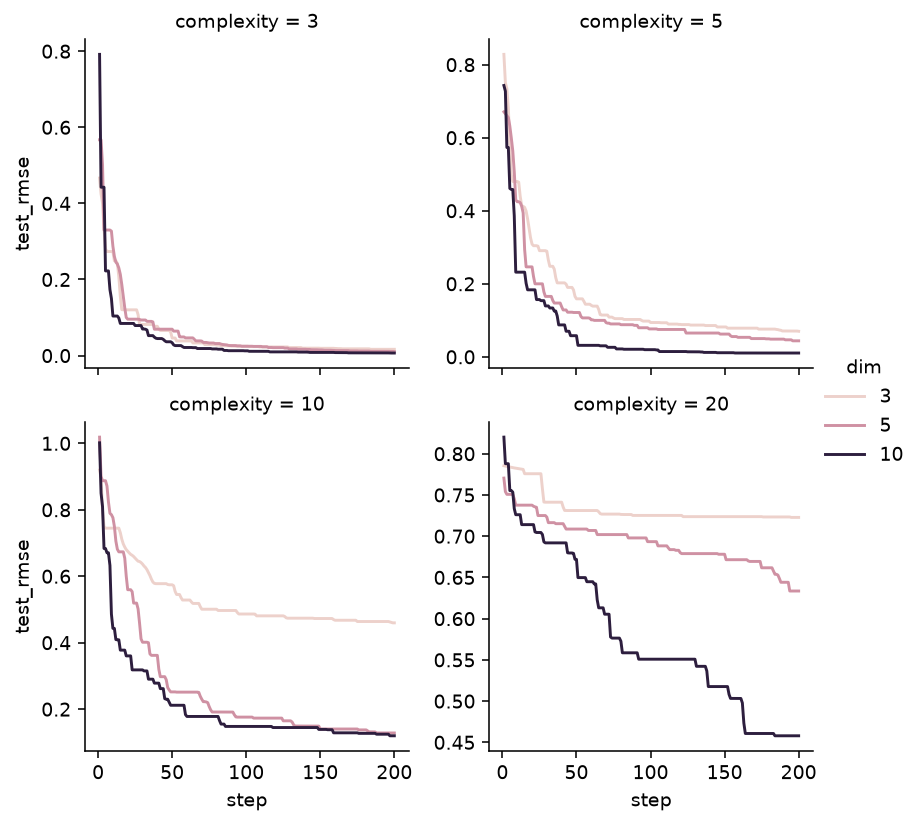

In [11]:
sns.relplot(scaling_laws_df, kind='line', x='step', y='test_rmse', col='complexity', hue='dim', 
            col_wrap=2, height=3, facet_kws={'sharey': False, 'sharex': True})

# Monotone functions

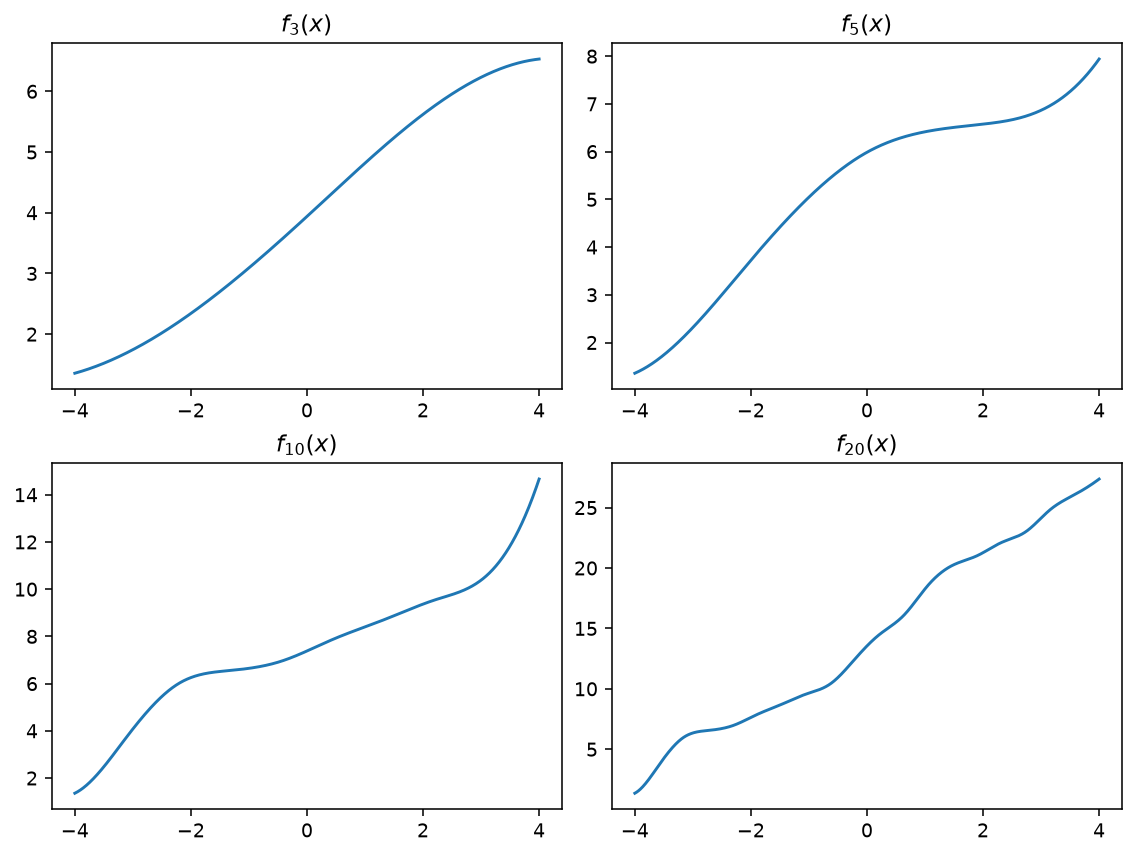

In [13]:
func_gallery(random_inc_func)
plt.show()

In [14]:
dims = [3, 5, 10]
complexities = [5, 20]
scaling_laws = []
for complexity in complexities:
    for dim in dims:
        scaling_law = compute_scaling_law(
            Synthetic1DStream(random_inc_func(complexity)),
            lambda: KthEigval1DMonotone(1, dim)
        )
        scaling_law['dim'] = dim
        scaling_law['complexity'] = complexity
        scaling_law['kind'] = 'monotone'
        scaling_laws.append(scaling_law.reset_index())
        print(f'Computed dim={dim}, complexity={complexity}, kind = monotone')
        
        scaling_law = compute_scaling_law(
            Synthetic1DStream(random_inc_func(complexity)),
            lambda: KthEigval(1, dim)
        )
        scaling_law['dim'] = dim
        scaling_law['complexity'] = complexity
        scaling_law['kind'] = 'generic'
        scaling_laws.append(scaling_law.reset_index())
        print(f'Computed dim={dim}, complexity={complexity}, kind = generic')

IndexError: index 3 is out of bounds for dimension 1 with size 1